In [1]:
# reflected location error in ozone data simulation

import torch
import torch.fft
import numpy as np
import sys
import os
import logging
import argparse 
import pandas as pd
import pickle
import torch.optim as optim
import copy
import time
from sklearn.neighbors import BallTree
from typing import Optional, List, Tuple
from pathlib import Path

# --- CUSTOM PATHS ---
gems_tco_path = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
sys.path.append(gems_tco_path)

# (필요 시 실제 GEMS_TCO 라이브러리 import)
try:
    from GEMS_TCO import kernels_for_simulation_no_trend_020626 as kernels_simulation
    
    from GEMS_TCO import kernels_columns as kernels_reparam_space_time_gpu_col
    
    from GEMS_TCO import orderings as _orderings
    from GEMS_TCO import alg_optimization, BaseLogger


except ImportError:
    print("Warning: GEMS_TCO modules not found. Ensure paths are correct.")


from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data2, exact_location_filter
from GEMS_TCO import debiased_whittle





In [2]:
space: List[str] = ['1', '1']
lat_lon_resolution = [int(s) for s in space]
mm_cond_number: int = 8
years = ['2024']
month_range = [7] 

output_path = input_path = Path(config.mac_estimates_day_path)
data_load_instance = load_data2(config.mac_data_load_path)

#lat_range_input = [1, 3]
#lon_range_input = [125.0, 129.0]

lat_range_input=[-3,-1]      
lon_range_input=[121, 125] 

lat_range_input=[-3,2]      
lon_range_input=[121, 131] 

# 기존: df_map, ord_mm, nns_map, day_offsets = ...
# 수정 후: 변수명을 monthly_mean으로 변경

df_map, ord_mm, nns_map, monthly_mean = data_load_instance.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=lat_lon_resolution, 
    mm_cond_number=mm_cond_number,
    years_=years, 
    months_=month_range,
    lat_range=lat_range_input,   
    lon_range=lon_range_input
)

print(f"Global Monthly Mean: {monthly_mean}") # 확인용 출력


daily_aggregated_reg_vecc = [] 
daily_hourly_maps_reg_vecc = []      

daily_aggregated_irr_vecc = [] 
daily_hourly_maps_irr_vecc = []   


for day_index in range(31):
    hour_start_index = day_index * 8
    
    hour_end_index = (day_index + 1) * 8
    #hour_end_index = day_index*8 + 1
    hour_indices = [hour_start_index, hour_end_index]

    day_hourly_map, day_aggregated_tensor = data_load_instance.load_working_data(
    df_map, 
    monthly_mean,  # <--- 이 부분이 추가되어야 합니다
    hour_indices, 
    ord_mm=ord_mm,
    dtype=torch.float64, 
    keep_ori=False
    )

    daily_aggregated_reg_vecc.append( day_aggregated_tensor )
    daily_hourly_maps_reg_vecc.append( day_hourly_map )

    day_hourly_map, day_aggregated_tensor = data_load_instance.load_working_data(
    df_map, 
    monthly_mean,  # <--- 이 부분이 추가되어야 합니다
    hour_indices, 
    ord_mm=ord_mm,
    dtype=torch.float64, 
    keep_ori= True
    )

    daily_aggregated_irr_vecc.append( day_aggregated_tensor )
    daily_hourly_maps_irr_vecc.append( day_hourly_map )
print(daily_aggregated_irr_vecc[0].shape)

nn = daily_aggregated_irr_vecc[0].shape[0]

--- Global Monthly Mean for 2024-7: 258.0436 ---
Global Monthly Mean: 258.0436023045006
torch.Size([145008, 11])


고해상도 latitude *100 longitude *4 - real data location - match high resolution data - again regular grid

In [35]:
def generate_high_res_field(target_lat_range, target_lon_range, t_steps, params, device, dtype):
    # 연속 공간 유지를 위해 고해상도 사용
    lat_res_factor, lon_res_factor = 100, 20  

    lat_res_high = 0.044 / lat_res_factor
    lon_res_high = 0.063 / lon_res_factor
    
    t_lat_max = max(target_lat_range)
    t_lat_min = min(target_lat_range)
    
    lats_high = torch.arange(t_lat_max + 0.1, t_lat_min - 0.1, -lat_res_high, device=device, dtype=dtype)
    lons_high = torch.arange(target_lon_range[0] - 0.1, target_lon_range[1] + 0.1, lon_res_high, device=device, dtype=dtype)
    
    Nx, Ny, Nt = len(lats_high), len(lons_high), t_steps
    dlat, dlon, dt = lat_res_high, lon_res_high, 1.0
    
    Px, Py, Pt = 2*Nx, 2*Ny, 2*Nt
    lags_x = torch.arange(Px, device=device, dtype=dtype) * dlat; lags_x[Px//2:] -= (Px * dlat)
    lags_y = torch.arange(Py, device=device, dtype=dtype) * dlon; lags_y[Py//2:] -= (Py * dlon)
    lags_t = torch.arange(Pt, device=device, dtype=dtype) * dt;   lags_t[Pt//2:] -= (Pt * dt)

    L_x, L_y, L_t = torch.meshgrid(lags_x, lags_y, lags_t, indexing='ij')
    phi1, phi2, phi3, phi4 = torch.exp(params[0]), torch.exp(params[1]), torch.exp(params[2]), torch.exp(params[3])
    adv_lat, adv_lon = params[4], params[5]
    sigma_sq = phi1 / phi2 
    
    u_x = L_x - adv_lat * L_t
    u_y = L_y - adv_lon * L_t
    dist_sq = (u_x * torch.sqrt(phi3) * phi2)**2 + (u_y * phi2)**2 + (L_t * torch.sqrt(phi4) * phi2)**2
    C_vals = sigma_sq * torch.exp(-torch.sqrt(dist_sq + 1e-12))

    S = torch.fft.fftn(C_vals); S.real = torch.clamp(S.real, min=0)
    random_phase = torch.fft.fftn(torch.randn(Px, Py, Pt, device=device, dtype=dtype))
    field_sim_raw = torch.fft.ifftn(torch.sqrt(S.real) * random_phase).real
    
    field_sim = field_sim_raw[:Nx, :Ny, :Nt]
    target_std = torch.sqrt(sigma_sq)
    field_calibrated = (field_sim - field_sim.mean()) * (target_std / (field_sim.std() + 1e-9))
    
    return field_calibrated, lats_high, lons_high

In [36]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.neighbors import BallTree
import sys

# --- 1. CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
print(f"Simulating on: {DEVICE}")

# --- 2. GRID & FFT HELPERS ---
def make_target_grid(lat_start, lat_end, lat_step, lon_start, lon_end, lon_step, device, dtype):
    if lat_start > lat_end and lat_step > 0: lat_step = -lat_step
    if lon_start > lon_end and lon_step > 0: lon_step = -lon_step
    lats = torch.arange(lat_start, lat_end - 0.0001, lat_step, device=device, dtype=dtype)
    lons = torch.arange(lon_start, lon_end + 0.0001, lon_step, device=device, dtype=dtype)
    lats = torch.round(lats * 10000) / 10000
    lons = torch.round(lons * 10000) / 10000
    grid_lat, grid_lon = torch.meshgrid(lats, lons, indexing='ij')
    center_points = torch.stack([grid_lat.flatten(), grid_lon.flatten()], dim=1)
    return center_points, len(lats), len(lons)



# --- 3. [NO TREND] 3-WAY DATASET GENERATOR ---
def generate_three_datasets_no_trend(daily_maps_real, true_params_tensor, target_grid_info, device, dtype):
    
    lat_s, lat_e, lat_step, lon_s, lon_e, lon_step = target_grid_info
    
    target_grid_coords, Nx, Ny = make_target_grid(lat_s, lat_e, lat_step, lon_s, lon_e, lon_step, device, dtype)
    full_grid_locs_np = target_grid_coords.cpu().numpy()
    
    # 격자 중심 탐색을 위한 Tree
    target_tree = BallTree(np.radians(full_grid_locs_np), metric='haversine') 
    
    high_res_field, lats_high, lons_high = generate_high_res_field((lat_s, lat_e), (lon_s, lon_e), 8, true_params_tensor, device, dtype)
    
    hr_mesh_lat, hr_mesh_lon = torch.meshgrid(lats_high, lons_high, indexing='ij')
    hr_tree = BallTree(np.radians(torch.stack([hr_mesh_lat.flatten(), hr_mesh_lon.flatten()], dim=1).cpu().numpy()), metric='haversine')
    high_res_flat = high_res_field.reshape(-1, 8) 

    list_irr, list_reg, list_dw = [], [], []
    map_irr, map_reg, map_dw = {}, {}, {}

    noise_std = torch.sqrt(torch.exp(true_params_tensor[6]))
    GLOBAL_MEAN = 260.0 

    day0_dict = daily_maps_real[0]

    sorted_keys = sorted([k for k in day0_dict.keys() if 'hm' in k or 'time' in k])
    
    for t_idx, key in enumerate(sorted_keys):
        if t_idx >= 8: break
        
        real_tensor = day0_dict[key].to(device)
        real_locs = real_tensor[:, :2]
        real_locs_np = real_locs.cpu().numpy()
        
        # -------------------------------------------------------------
        # 1. Vecc Irr (실제 L2 관측값 생성)
        # -------------------------------------------------------------
        _, hr_indices_irr = hr_tree.query(np.radians(real_locs_np), k=1)
        gp_signal_irr = high_res_flat[torch.tensor(hr_indices_irr.flatten(), device=device), t_idx]
        
        # 위성이 궤도에서 측정한 참값 + 측정 노이즈
        sim_vals_irr = gp_signal_irr + (torch.randn_like(gp_signal_irr) * noise_std) + GLOBAL_MEAN
        
        irr_row = torch.cat([real_locs, sim_vals_irr.unsqueeze(-1), real_tensor[:, 3].unsqueeze(-1)], dim=1)
        list_irr.append(irr_row)
        map_irr[key] = irr_row
        
        # -------------------------------------------------------------
        # 2. Vecc Reg (데이터 중심 - Drop-in the bucket)
        # -------------------------------------------------------------
        # 궤도 데이터를 가장 가까운 격자로 억지로 밀어넣음 (결측치/중복 발생)
        _, grid_indices = target_tree.query(np.radians(real_locs_np), k=1)
        grid_indices = grid_indices.flatten()
        
        mapped_locs = target_grid_coords[torch.tensor(grid_indices, device=device)]
        reg_row = torch.cat([mapped_locs, sim_vals_irr.unsqueeze(-1), real_tensor[:, 3].unsqueeze(-1)], dim=1)
        list_reg.append(reg_row)
        map_reg[key] = reg_row

        # -------------------------------------------------------------
        # ★ 3. DW (격자 중심 - Nearest Neighbor Resampling) ★
        # -------------------------------------------------------------
        # 꽉 찬 바둑판 격자에서, 가장 가까운 위성 궤도 데이터를 훔쳐옴 (결측치 원천 차단)
        real_tree = BallTree(np.radians(real_locs_np), metric='haversine')
        _, nearest_irr_idx = real_tree.query(np.radians(full_grid_locs_np), k=1)
        nearest_irr_idx = nearest_irr_idx.flatten()
        
        # 각 격자점에 가장 가까운 실제 관측값을 배정 (시공간 표류에 의한 100% 순수 Warping 발생!)
        sim_vals_dw = sim_vals_irr[nearest_irr_idx]
        
        time_col_dw = torch.full((len(target_grid_coords), 1), float(t_idx), device=device, dtype=dtype)
        dw_row = torch.cat([target_grid_coords, sim_vals_dw.unsqueeze(-1), time_col_dw], dim=1)
        list_dw.append(dw_row)
        map_dw[key] = dw_row

    return (
        (torch.cat(list_irr), map_irr),  
        (torch.cat(list_reg), map_reg),  
        (torch.cat(list_dw), map_dw)     
    )

# --- 4. EXECUTION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
target_grid_info = (-1.0, -3.0, 0.044, 121.0, 125.0, 0.063)

# True Params
init_sigmasq   = 13.059
init_range_lon = 0.195 
init_range_lat = 0.154 
init_range_time = 1.0
init_nugget    = 0.247
init_advec_lat = 0.0418
init_advec_lon = -0.1689

true_phi2 = 1.0 / init_range_lon              
true_phi1 = init_sigmasq * true_phi2          
true_phi3 = (init_range_lon / init_range_lat)**2
true_phi4 = (init_range_lon / init_range_time)**2

true_params_tensor = [
    torch.tensor([np.log(true_phi1)], device=DEVICE, dtype=DTYPE),
    torch.tensor([np.log(true_phi2)], device=DEVICE, dtype=DTYPE),
    torch.tensor([np.log(true_phi3)], device=DEVICE, dtype=DTYPE),
    torch.tensor([np.log(true_phi4)], device=DEVICE, dtype=DTYPE),
    torch.tensor([init_advec_lat],    device=DEVICE, dtype=DTYPE),
    torch.tensor([init_advec_lon],    device=DEVICE, dtype=DTYPE),
    torch.tensor([np.log(init_nugget)], device=DEVICE, dtype=DTYPE)
]

print("Checking Inputs:")
print(f" -> Target SigmaSq: {init_sigmasq}")

if 'daily_hourly_maps_irr_vecc' in locals() and len(daily_hourly_maps_irr_vecc) > 0:
    print("\n🚀 Generating 3 Datasets (NO TREND, 4 COLS)...")
    
    (vecc_irr_data, vecc_reg_data, dw_full_data) = generate_three_datasets_no_trend(
        daily_hourly_maps_irr_vecc, true_params_tensor, target_grid_info, DEVICE, DTYPE
    )
    
    agg_irr, map_irr = vecc_irr_data
    agg_reg, map_reg = vecc_reg_data
    agg_dw,  map_dw  = dw_full_data
    
    daily_aggregated_irr_vecc_sim = [agg_irr]
    daily_hourly_maps_irr_vecc_sim = [map_irr]
    
    daily_aggregated_reg_vecc_sim = [agg_reg] 
    daily_hourly_maps_reg_vecc_sim = [map_reg]
    
    daily_aggregated_dw_sim = [agg_dw] 
    daily_hourly_maps_dw_sim = [map_dw]
    
    print(f"\n[Validation]")
    print(f"1. Vecc Irr (Swath): {agg_irr.shape} (Cols: 4)")
    print(f"2. Vecc Reg (Snapped): {agg_reg.shape} (Cols: 4)")
    print(f"3. DW Full (Grid-Centric): {agg_dw.shape} (Cols: 4)")

else:
    print("Error: Load data first.")

# ★ 1. DW 데이터 (결측치 없는 격자 중심 매칭 데이터) 를 가져옵니다!
dw_tensor = daily_aggregated_dw_sim[0]
coords_dw = dw_tensor[:, :2].cpu().numpy()

print(f"Generating NNS Map for DW Grid (Size: {len(coords_dw)})...")

# 2. MaxMin Ordering
ord_mm_dw = _orderings.maxmin_cpp(coords_dw)
dw_tensor_ordered = dw_tensor[ord_mm_dw]  

# 3. DW용 NNS Map 생성
coords_dw_ordered = dw_tensor_ordered[:, :2].cpu().numpy()
nns_map_dw = _orderings.find_nns_l2(locs=coords_dw_ordered, max_nn=mm_cond_number)

Simulating on: cpu
Checking Inputs:
 -> Target SigmaSq: 13.059

🚀 Generating 3 Datasets (NO TREND, 4 COLS)...

[Validation]
1. Vecc Irr (Swath): torch.Size([145008, 4]) (Cols: 4)
2. Vecc Reg (Snapped): torch.Size([145008, 4]) (Cols: 4)
3. DW Full (Grid-Centric): torch.Size([23552, 4]) (Cols: 4)
Generating NNS Map for DW Grid (Size: 23552)...


고해상도 latitude *100 longitude *4 - random iid jitter - match high resolution data - again regular grid

In [33]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.neighbors import BallTree
import sys

# --- 1. CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
print(f"Simulating on: {DEVICE}")

# --- 2. GRID & FFT HELPERS ---
def make_target_grid(lat_start, lat_end, lat_step, lon_start, lon_end, lon_step, device, dtype):
    if lat_start > lat_end and lat_step > 0: lat_step = -lat_step
    if lon_start > lon_end and lon_step > 0: lon_step = -lon_step
    lats = torch.arange(lat_start, lat_end - 0.0001, lat_step, device=device, dtype=dtype)
    lons = torch.arange(lon_start, lon_end + 0.0001, lon_step, device=device, dtype=dtype)
    lats = torch.round(lats * 10000) / 10000
    lons = torch.round(lons * 10000) / 10000
    grid_lat, grid_lon = torch.meshgrid(lats, lons, indexing='ij')
    center_points = torch.stack([grid_lat.flatten(), grid_lon.flatten()], dim=1)
    return center_points, len(lats), len(lons)

def generate_high_res_field(target_lat_range, target_lon_range, t_steps, params, device, dtype):
    # ★ 연속 공간(대자연)을 모사하기 위해 고해상도 유지
    lat_res_factor, lon_res_factor = 200.0, 4.0  

    lat_res_high = 0.044 / lat_res_factor
    lon_res_high = 0.063 / lon_res_factor
    
    t_lat_max = max(target_lat_range)
    t_lat_min = min(target_lat_range)
    
    lats_high = torch.arange(t_lat_max + 0.1, t_lat_min - 0.1, -lat_res_high, device=device, dtype=dtype)
    lons_high = torch.arange(target_lon_range[0] - 0.1, target_lon_range[1] + 0.1, lon_res_high, device=device, dtype=dtype)
    
    Nx, Ny, Nt = len(lats_high), len(lons_high), t_steps
    dlat, dlon, dt = lat_res_high, lon_res_high, 1.0
    
    Px, Py, Pt = 2*Nx, 2*Ny, 2*Nt
    lags_x = torch.arange(Px, device=device, dtype=dtype) * dlat; lags_x[Px//2:] -= (Px * dlat)
    lags_y = torch.arange(Py, device=device, dtype=dtype) * dlon; lags_y[Py//2:] -= (Py * dlon)
    lags_t = torch.arange(Pt, device=device, dtype=dtype) * dt;   lags_t[Pt//2:] -= (Pt * dt)

    L_x, L_y, L_t = torch.meshgrid(lags_x, lags_y, lags_t, indexing='ij')
    phi1, phi2, phi3, phi4 = torch.exp(params[0]), torch.exp(params[1]), torch.exp(params[2]), torch.exp(params[3])
    adv_lat, adv_lon = params[4], params[5]
    sigma_sq = phi1 / phi2 
    
    u_x = L_x - adv_lat * L_t
    u_y = L_y - adv_lon * L_t
    dist_sq = (u_x * torch.sqrt(phi3) * phi2)**2 + (u_y * phi2)**2 + (L_t * torch.sqrt(phi4) * phi2)**2
    C_vals = sigma_sq * torch.exp(-torch.sqrt(dist_sq + 1e-12))

    S = torch.fft.fftn(C_vals); S.real = torch.clamp(S.real, min=0)
    random_phase = torch.fft.fftn(torch.randn(Px, Py, Pt, device=device, dtype=dtype))
    field_sim_raw = torch.fft.ifftn(torch.sqrt(S.real) * random_phase).real
    
    field_sim = field_sim_raw[:Nx, :Ny, :Nt]
    target_std = torch.sqrt(sigma_sq)
    field_calibrated = (field_sim - field_sim.mean()) * (target_std / (field_sim.std() + 1e-9))
    
    return field_calibrated, lats_high, lons_high

# --- 3. [NO TREND] 3-WAY DATASET GENERATOR ---
def generate_three_datasets_no_trend(daily_maps_real, true_params_tensor, target_grid_info, device, dtype):
    
    lat_s, lat_e, lat_step, lon_s, lon_e, lon_step = target_grid_info
    
    # 1. Target Grid (Full)
    target_grid_coords, Nx, Ny = make_target_grid(lat_s, lat_e, lat_step, lon_s, lon_e, lon_step, device, dtype)
    full_grid_locs_np = target_grid_coords.cpu().numpy()
    target_tree = BallTree(np.radians(full_grid_locs_np), metric='haversine') 
    
    # 2. High-Res GP Field
    high_res_field, lats_high, lons_high = generate_high_res_field((lat_s, lat_e), (lon_s, lon_e), 8, true_params_tensor, device, dtype)
    
    hr_mesh_lat, hr_mesh_lon = torch.meshgrid(lats_high, lons_high, indexing='ij')
    hr_tree = BallTree(np.radians(torch.stack([hr_mesh_lat.flatten(), hr_mesh_lon.flatten()], dim=1).cpu().numpy()), metric='haversine')
    high_res_flat = high_res_field.reshape(-1, 8) 

    # 저장소 (3종류)
    list_irr, list_reg, list_dw = [], [], []
    map_irr, map_reg, map_dw = {}, {}, {}

    noise_std = torch.sqrt(torch.exp(true_params_tensor[6]))
    GLOBAL_MEAN = 260.0 # No Trend, Just Mean

    day0_dict = daily_maps_real[0]
    sorted_keys = sorted([k for k in day0_dict.keys() if 'hm' in k or 'time' in k])
    
    # -------------------------------------------------------------
    # ★ Step A: Generate [DW Full] (Jitter 적용 완료)
    # -------------------------------------------------------------
    # 격자 중심에서 무작위로 빗나간 좌표를 만들어 High-res 값을 훔쳐옵니다.
    jitter_std = 0.2 # 격자 간격(0.044~0.063) 수준의 Jitter 부여
    
    jittered_grid_locs_np = full_grid_locs_np + np.random.normal(0, jitter_std, size=full_grid_locs_np.shape)
    
    # 빗나간 위치(jittered)로 고해상도 데이터를 탐색!
    _, hr_indices_full = hr_tree.query(np.radians(jittered_grid_locs_np), k=1)
    hr_indices_full = torch.tensor(hr_indices_full.flatten(), device=device)

    for t_idx in range(8):
        key = f"time_{t_idx}"
        
        # 여기서 뽑힌 gp_signal은 Y(k + ε) 값입니다.
        gp_signal = high_res_flat[hr_indices_full, t_idx]
        sim_vals = gp_signal + (torch.randn_like(gp_signal) * noise_std) + GLOBAL_MEAN
        
        N_full = len(target_grid_coords)
        time_col = torch.full((N_full, 1), float(t_idx), device=device, dtype=dtype)
        
        # 값(sim_vals)은 빗나간 곳의 값이지만, 저장되는 위치(target_grid_coords)는 정규 격자 중심!
        dw_row = torch.cat([target_grid_coords, sim_vals.unsqueeze(-1), time_col], dim=1)
        list_dw.append(dw_row)
        map_dw[key] = dw_row

    # -------------------------------------------------------------
    # ★ Step B: Generate [Vecc Irr] & [Vecc Reg] (Jitter 적용 완료)
    # -------------------------------------------------------------
    for t_idx, key in enumerate(sorted_keys):
        if t_idx >= 8: break
        
        real_tensor = day0_dict[key].to(device)
        real_locs = real_tensor[:, :2]
        N_points = len(real_locs)
        real_locs_np = real_locs.cpu().numpy()
        


        # 1. Vecc Irr (Original Coords) - 실제 위치에서의 관측값
        _, hr_indices_irr = hr_tree.query(np.radians(real_locs_np), k=1)
        gp_signal_irr = high_res_flat[torch.tensor(hr_indices_irr.flatten(), device=device), t_idx]
        
        sim_vals_irr = gp_signal_irr + (torch.randn_like(gp_signal_irr) * noise_std) + GLOBAL_MEAN
        
        # 4 Cols
        irr_row = torch.cat([
            real_locs, 
            sim_vals_irr.unsqueeze(-1), 
            real_tensor[:, 3].unsqueeze(-1)
        ], dim=1)
        list_irr.append(irr_row)
        map_irr[key] = irr_row
        
        # 2. Vecc Reg (Snapped Coords)
        _, grid_indices = target_tree.query(np.radians(real_locs_np), k=1)
        grid_indices = grid_indices.flatten()
        
        # ★ 핵심: 캐시된 정답이 아니라, 방금 관측한 실제 값(sim_vals_irr)을 억지로 욱여넣음!
        sim_vals_reg = sim_vals_irr
        mapped_locs = target_grid_coords[torch.tensor(grid_indices, device=device)]
        
        # 4 Cols
        reg_row = torch.cat([
            mapped_locs, 
            sim_vals_reg.unsqueeze(-1), 
            real_tensor[:, 3].unsqueeze(-1)
        ], dim=1)
        list_reg.append(reg_row)
        map_reg[key] = reg_row

    # Returns 3 Tuples
    return (
        (torch.cat(list_irr), map_irr),  # 1. Irr
        (torch.cat(list_reg), map_reg),  # 2. Reg
        (torch.cat(list_dw), map_dw)     # 3. DW
    )

# --- 4. EXECUTION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
target_grid_info = (-1.0, -3.0, 0.044, 121.0, 125.0, 0.063)

# True Params
init_sigmasq   = 13.059
init_range_lon = 0.195 
init_range_lat = 0.154 
init_range_time = 1.0
init_nugget    = 0.247



init_advec_lat = 0.0418
init_advec_lon = -0.1689

true_phi2 = 1.0 / init_range_lon              
true_phi1 = init_sigmasq * true_phi2          
true_phi3 = (init_range_lon / init_range_lat)**2
true_phi4 = (init_range_lon / init_range_time)**2

true_params_tensor = [
    torch.tensor([np.log(true_phi1)], device=DEVICE, dtype=DTYPE),
    torch.tensor([np.log(true_phi2)], device=DEVICE, dtype=DTYPE),
    torch.tensor([np.log(true_phi3)], device=DEVICE, dtype=DTYPE),
    torch.tensor([np.log(true_phi4)], device=DEVICE, dtype=DTYPE),
    torch.tensor([init_advec_lat],    device=DEVICE, dtype=DTYPE),
    torch.tensor([init_advec_lon],    device=DEVICE, dtype=DTYPE),
    torch.tensor([np.log(init_nugget)], device=DEVICE, dtype=DTYPE)
]

print("Checking Inputs:")
print(f" -> Target SigmaSq: {init_sigmasq}")

if 'daily_hourly_maps_irr_vecc' in locals() and len(daily_hourly_maps_irr_vecc) > 0:
    print("\n🚀 Generating 3 Datasets (NO TREND, 4 COLS)...")
    
    (vecc_irr_data, vecc_reg_data, dw_full_data) = generate_three_datasets_no_trend(
        daily_hourly_maps_irr_vecc, true_params_tensor, target_grid_info, DEVICE, DTYPE
    )
    
    # Unpack
    agg_irr, map_irr = vecc_irr_data
    agg_reg, map_reg = vecc_reg_data
    agg_dw,  map_dw  = dw_full_data
    
    # Global Variables for Models
    daily_aggregated_irr_vecc_sim = [agg_irr]
    daily_hourly_maps_irr_vecc_sim = [map_irr]
    
    daily_aggregated_reg_vecc_sim = [agg_reg] 
    daily_hourly_maps_reg_vecc_sim = [map_reg]
    
    daily_aggregated_dw_sim = [agg_dw] 
    daily_hourly_maps_dw_sim = [map_dw]
    
    print(f"\n[Validation]")
    print(f"1. Vecc Irr (Swath): {agg_irr.shape} (Cols: 4)")
    print(f"2. Vecc Reg (Snapped): {agg_reg.shape} (Cols: 4)")
    print(f"3. DW Full (Complete): {agg_dw.shape} (Cols: 4)")
    
    print(f"   -> DW Val Mean: {agg_dw[:, 2].mean().item():.2f}")

else:
    print("Error: Load data first.")

# 1. DW 데이터 가져오기
dw_tensor = daily_aggregated_dw_sim[0]
coords_dw = dw_tensor[:, :2].cpu().numpy()

print(f"Generating NNS Map for Full Grid (Size: {len(coords_dw)})...")

# 2. MaxMin Ordering 수행
ord_mm_dw = _orderings.maxmin_cpp(coords_dw)
dw_tensor_ordered = dw_tensor[ord_mm_dw]  

# 3. DW용 NNS Map 생성
coords_dw_ordered = dw_tensor_ordered[:, :2].cpu().numpy()
nns_map_dw = _orderings.find_nns_l2(locs=coords_dw_ordered, max_nn=mm_cond_number)

Simulating on: cpu
Checking Inputs:
 -> Target SigmaSq: 13.059

🚀 Generating 3 Datasets (NO TREND, 4 COLS)...

[Validation]
1. Vecc Irr (Swath): torch.Size([145008, 4]) (Cols: 4)
2. Vecc Reg (Snapped): torch.Size([145008, 4]) (Cols: 4)
3. DW Full (Complete): torch.Size([23552, 4]) (Cols: 4)
   -> DW Val Mean: 260.08
Generating NNS Map for Full Grid (Size: 23552)...


# Fit vecchia max min time 2 

reg sim  에러나는 이유는 데이터 중복 snap 때문

중요! reg sim 은 데이터 중심, 실제 데이터 위치에서 가장 가까운 그리드로 이동 이래서 중복 가능, 콜레스키 깨지기도 

dw 는 그리드 중심, 타겟 레귤러 그리드에서 가장 가까운 점 가져오기 

In [37]:
import torch
import numpy as np
import time

# --- CONFIGURATION ---
v = 0.5              # Smoothness
mm_cond_number = 8   # Neighbors
#mm_cond_number = 16   # Neighbors
nheads = 300           # 0 = Pure Vecchia
lr = 1.0             # LBFGS learning rate
LBFGS_MAX_STEPS = 2
LBFGS_HISTORY_SIZE = 100 # 100
LBFGS_LR = 1.0
LBFGS_MAX_EVAL = 30    

#DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# --- 1. SETUP PARAMETERS (List of Scalars) ---
# Truth: [4.18, 1.94, 0.24, -3.97, 0.014, -0.20, -0.85]
init_sigmasq   = 13.059
init_range_lat = 0.154 
init_range_lon = 0.195
init_advec_lat = 0.0218
init_range_time = 1.0
init_advec_lon = -0.1689
init_nugget    = 0.247


# Map model parameters to the 'phi' reparameterization
init_phi2 = 1.0 / init_range_lon                # 1/range_lon
init_phi1 = init_sigmasq * init_phi2            # sigmasq / range_lon
init_phi3 = (init_range_lon / init_range_lat)**2  # (range_lon / range_lat)^2
init_phi4 = (init_range_lon / init_range_time)**2      # (range_lon / range_time)^2

# Create Initial Parameters (Float64, Requires Grad)
initial_vals = [np.log(init_phi1), np.log(init_phi2), np.log(init_phi3), 
                np.log(init_phi4), init_advec_lat, init_advec_lon, np.log(init_nugget)]

# [4.2042, 1.6348, 0.4721, -3.2695, 0.0218, -0.1689, -1.3984]
params_list = [
    torch.tensor([val], requires_grad=True, dtype=torch.float64, device=DEVICE)
    for val in initial_vals
]

# --- 2. INSTANTIATE MODEL ---
print(f'\n{"="*40}')
print(f'--- Initializing VecchiaBatched Model ---')
print(f'{"="*40}')

#if isinstance(daily_aggregated_irr_vecc_sim, torch.Tensor):
#    daily_aggregated_irr_vecc_sim = daily_aggregated_irr_vecc_sim.to(DEVICE)

# Instantiate
model_instance = kernels_simulation.fit_vecchia_lbfgs(
    smooth=v,

    #input_map=daily_hourly_maps_reg_vecc_sim[0],
    #aggregated_data= daily_aggregated_reg_vecc_sim[0],

    #input_map=daily_hourly_maps_irr_vecc_sim[0],
    #aggregated_data= daily_aggregated_irr_vecc_sim[0],

    input_map=daily_hourly_maps_dw_sim[0],
    aggregated_data= daily_aggregated_dw_sim[0],
    
    nns_map=nns_map_dw,     # or nns_map for the swath data
    mm_cond_number=mm_cond_number,
    nheads=nheads
)

'''
model_instance = kernels_reparam_space_time_gpu_col.fit_vecchia_lbfgs(
    smooth=v,
    #input_map=daily_hourly_maps_vecc_sim[0],
    #aggregated_data= daily_aggregated_tensors_vecc_sim[0],

    input_map=daily_hourly_maps_irr_vecc_sim[0],
    aggregated_data= daily_aggregated_irr_vecc_sim[0],

    nns_map=None,
    mm_cond_number=mm_cond_number
)
''' 

# --- 3. OPTIMIZATION LOOP ---
print(f'\n{"="*40}')
print(f'--- Running L-BFGS Optimization ---')
print(f'{"="*40}')

# Optimizer takes the LIST of scalars
optimizer_vecc = model_instance.set_optimizer(
            params_list,     
            lr=LBFGS_LR,            
            max_iter=LBFGS_MAX_EVAL,        
            history_size=LBFGS_HISTORY_SIZE 
        )

start_time = time.time()

out, steps_ran = model_instance.fit_vecc_lbfgs(
        params_list,
        optimizer_vecc,
        # covariance_function argument is GONE
        max_steps=LBFGS_MAX_STEPS, 
        grad_tol=1e-7
    )


end_time = time.time()
epoch_time = end_time - start_time

print(f"\nOptimization finished in {epoch_time:.2f}s.")
print(f"Results after {steps_ran} steps: {out}")
print(f"Final Params: {torch.cat(params_list).detach().cpu().numpy()}")

Using device: cpu

--- Initializing VecchiaBatched Model ---

--- Running L-BFGS Optimization ---
🚀 Pre-computing (Only Intercept Mean Function)... ✅ Done. (Heads: 2400, Tails: 21152)
--- Starting Batched L-BFGS Optimization (GPU) ---
--- Step 1/2 / Loss: 1.689740 ---
  Param 0: Value=4.0560, Grad=5.590904559088852e-06
  Param 1: Value=1.5277, Grad=-7.455629204498903e-06
  Param 2: Value=0.7684, Grad=-7.009153808427027e-07
  Param 3: Value=-2.7201, Grad=-3.450405578359094e-07
  Param 4: Value=0.0251, Grad=4.087876452918762e-06
  Param 5: Value=-0.1303, Grad=-1.984201734266458e-06
  Param 6: Value=-0.5880, Grad=1.1647327427598102e-07
  Max Abs Grad: 7.455629e-06
------------------------------
--- Step 2/2 / Loss: 1.688885 ---
  Param 0: Value=4.0560, Grad=5.590904559088852e-06
  Param 1: Value=1.5277, Grad=-7.455629204498903e-06
  Param 2: Value=0.7684, Grad=-7.009153808427027e-07
  Param 3: Value=-2.7201, Grad=-3.450405578359094e-07
  Param 4: Value=0.0251, Grad=4.087876452918762e-06
 

두 번쨰 시뮬

Final Interpretable Params: {'sigma_sq': 9.551982909540676, 'range_lon': 0.1378884335487348, 'range_lat': 0.1026181784576705, 'range_time': 1.0932639209396704, 'advec_lat': -0.0024257695426708756, 'advec_lon': -0.003342477662103162, 'nugget': 5.204236347253712}


Final Interpretable Params: {'sigma_sq': 13.156149552197933, 'range_lon': 0.04489331005386974, 'range_lat': 0.03308062519003865, 'range_time': 0.7390745551921207, 'advec_lat': 0.0031149977600142885, 'advec_lon': -0.00943820113283815, 'nugget': 0.6788586156039527}


Final Interpretable Params: {'sigma_sq': 8.717229054500079, 'range_lon': 0.14510370696819602, 'range_lat': 0.1661735158184949, 'range_time': 1.186118278371051, 'advec_lat': 0.011128735234251204, 'advec_lon': -0.04171328343144129, 'nugget': 5.233022837837519}

Final Interpretable Params: {'sigma_sq': 11.54485557086427, 'range_lon': 0.04947654175150635, 'range_lat': 0.03408998525337347, 'range_time': 0.9219249235925719, 'advec_lat': 0.006048806185195888, 'advec_lon': -0.00929664007403721, 'nugget': 1.9764962946215234}

Final Interpretable Params: {'sigma_sq': 12.234184783393902, 'range_lon': 0.05528524642453865, 'range_lat': 0.0381704302553748, 'range_time': 0.8286461241660004, 'advec_lat': 0.0006900511186192963, 'advec_lon': -0.007867725540892682, 'nugget': 1.9495120028622517}

Final Interpretable Params: {'sigma_sq': 12.402960097969103, 'range_lon': 0.0013263953284875553, 'range_lat': 4.9196100874196225e-05, 'range_time': 3.5793761062457397, 'advec_lat': -0.005363064703112977, 'advec_lon': 0.09709480539382953, 'nugget': 1.1638393432991019}


Final Interpretable Params: {'sigma_sq': 11.006048147734408, 'range_lon': 0.05970461340817225, 'range_lat': 0.040483977030469936, 'range_time': 0.9441683202790678, 'advec_lat': 0.0052279632995084115, 'advec_lon': -0.0004414513193970004, 'nugget': 2.3951897333764145}



실제 데이터 모방 첫번째 시뮬레이션 블락

원래 크기 아래는 작은 거기 

50* 20
Final Interpretable Params: {'sigma_sq': 12.701108576453704, 'range_lon': 0.15873263525444536, 'range_lat': 0.11748040485672358, 'range_time': 0.791505004993584, 'advec_lat': -0.046180527951358616, 'advec_lon': -0.19186712915654808, 'nugget': 3.6724723580568637e-06}

Final Interpretable Params: {'sigma_sq': 13.093818831828035, 'range_lon': 0.2096718503998681, 'range_lat': 0.18156477606997407, 'range_time': 1.0681149762162336, 'advec_lat': -0.11167144128289527, 'advec_lon': -0.16261161248752948, 'nugget': 0.5248934048709449}

Final Interpretable Params: {'sigma_sq': 12.203721936670318, 'range_lon': 0.2125804394666903, 'range_lat': 0.18259715270335306, 'range_time': 1.0631634979721387, 'advec_lat': -0.06097651581761957, 'advec_lon': -0.1643521055774359, 'nugget': 0.9075684378191125}

100*20
Final Interpretable Params: {'sigma_sq': 13.411451110566919, 'range_lon': 0.16799935644709565, 'range_lat': 0.14300875945835761, 'range_time': 0.9603350764449083, 'advec_lat': -0.031412679769336475, 'advec_lon': -0.18683547282050822, 'nugget': 8.84763960689243e-06}

Final Interpretable Params: {'sigma_sq': 13.458080361604152, 'range_lon': 0.20439547202186495, 'range_lat': 0.17751439655334775, 'range_time': 1.1749374525678822, 'advec_lat': -0.041284202588956015, 'advec_lon': -0.16656149720038382, 'nugget': 0.24507948054206338}

Final Interpretable Params: {'sigma_sq': 13.0991159197062, 'range_lon': 0.17328793628157685, 'range_lat': 0.1378434470485613, 'range_time': 0.8049291766428365, 'advec_lat': -0.010202342693952945, 'advec_lon': -0.1774931640584295, 'nugget': 2.051388634467842e-06}

Final Interpretable Params: {'sigma_sq': 12.531951791640122, 'range_lon': 0.21703778206498478, 'range_lat': 0.14780270415728736, 'range_time': 0.845660814628336, 'advec_lat': 0.025145276402611536, 'advec_lon': -0.13029547246388762, 'nugget': 0.5554626736133916}


init_sigmasq   = 13.059
init_range_lat = 0.154 
init_range_lon = 0.195
init_advec_lat = 0.0218
init_range_time = 1.0
init_advec_lon = -0.1689
init_nugget    = 0.247


50*40
Final Interpretable Params: {'sigma_sq': 14.15149734178516, 'range_lon': 0.21133810121714006, 'range_lat': 0.19267190283256075, 'range_time': 1.0653428106772196, 'advec_lat': -0.01870980476443907, 'advec_lon': -0.16480600461723285, 'nugget': 1.3048138674302792e-06}


200*4


Final Interpretable Params: {'sigma_sq': 12.813736802590302, 'range_lon': 0.148432824307421, 'range_lat': 0.15761657918676775, 'range_time': 0.8822488694646387, 'advec_lat': -0.10692136834042955, 'advec_lon': -0.15471182109787696, 'nugget': 7.454706033774221e-07}


Final Interpretable Params: {'sigma_sq': 13.224620487434397, 'range_lon': 0.1869919123422417, 'range_lat': 0.17432237423322625, 'range_time': 1.0859737620417766, 'advec_lat': -0.14187304588292404, 'advec_lon': -0.14766425435983951, 'nugget': 5.042653112019781e-07}

Final Interpretable Params: {'sigma_sq': 13.332780677377293, 'range_lon': 0.17332982231152977, 'range_lat': 0.19320756813378068, 'range_time': 0.9861351759367685, 'advec_lat': -0.06565241126190391, 'advec_lon': -0.16682736676872634, 'nugget': 1.7809450881845557e-05}

Final Interpretable Params: {'sigma_sq': 11.460451999131047, 'range_lon': 0.15238222093368334, 'range_lat': 0.1431484002952808, 'range_time': 0.9135710770959141, 'advec_lat': -0.1090823616996154, 'advec_lon': -0.16744629141402145, 'nugget': 0.0005727367184479143}

Final Interpretable Params: {'sigma_sq': 12.733831824381832, 'range_lon': 0.1746524416286321, 'range_lat': 0.17999718067255813, 'range_time': 1.020423375940089, 'advec_lat': -0.04506458614793581, 'advec_lon': -0.1651923933317284, 'nugget': 1.6284484037482933e-06}

Final Interpretable Params: {'sigma_sq': 13.187039729266967, 'range_lon': 0.18905969097447364, 'range_lat': 0.19654296695196788, 'range_time': 0.931890184842452, 'advec_lat': 0.009446395729176474, 'advec_lon': -0.1558028015757649, 'nugget': 0.1561152876004175}

Final Interpretable Params: {'sigma_sq': 12.339769862662859, 'range_lon': 0.16261907424886818, 'range_lat': 0.15186042725951904, 'range_time': 0.8614194670789578, 'advec_lat': -0.05624666736677013, 'advec_lon': -0.18166881942195784, 'nugget': 1.2154929513462575e-06}

Final Interpretable Params: {'sigma_sq': 12.691537204946977, 'range_lon': 0.17202728913419751, 'range_lat': 0.16948194868301467, 'range_time': 1.0968127513717039, 'advec_lat': -0.059275865601638215, 'advec_lon': -0.15715899269205416, 'nugget': 1.7218909585542838e-06}


Final Interpretable Params: {'sigma_sq': 14.573652840391496, 'range_lon': 0.19401834386617153, 'range_lat': 0.19692515616107006, 'range_time': 1.231322804747303, 'advec_lat': -0.07931226963868304, 'advec_lon': -0.14066503429650923, 'nugget': 2.587634441255261e-06}


플랏 첫 번째

✅ Loading DW Grid Data directly...
--- Generating Simulation Periodogram Comparison ---
Computing Irregular Vecchia (Expected via True Params)...
Computing Regular Vecchia (Expected via Fitted Params)...


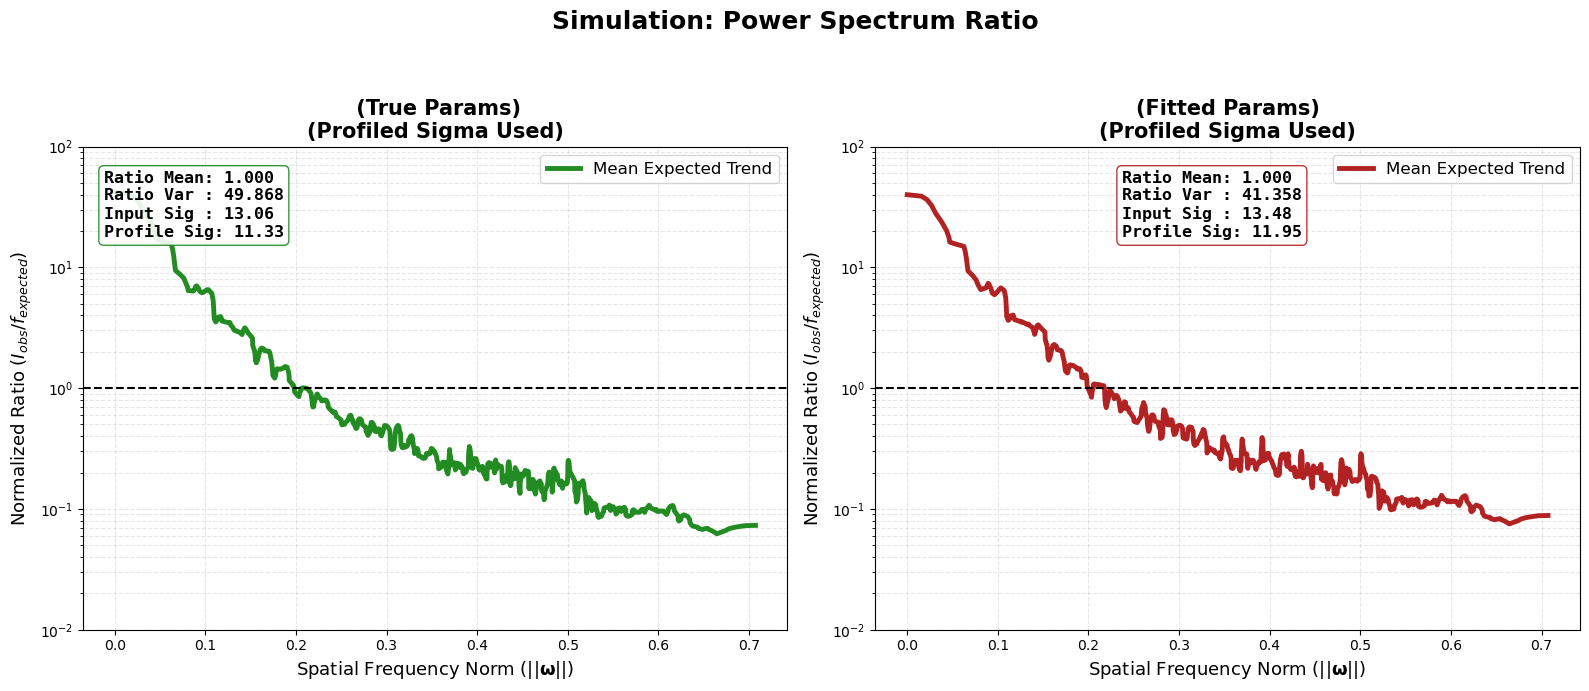

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftshift, fftfreq
from scipy.ndimage import gaussian_filter1d
import cmath
import sys
import pandas as pd

# =========================================================================
# 1. The Logic Class (Debiased Whittle Likelihood Core)
# =========================================================================
class debiased_whittle_likelihood:
    
    @staticmethod
    def cgn_hamming(u, n1, n2):
        u1, u2 = u
        device = u1.device if isinstance(u1, torch.Tensor) else (u2.device if isinstance(u2, torch.Tensor) else torch.device('cpu'))
        u1_tensor = u1.to(device) if isinstance(u1, torch.Tensor) else torch.tensor(u1, device=device, dtype=torch.float64)
        u2_tensor = u2.to(device) if isinstance(u2, torch.Tensor) else torch.tensor(u2, device=device, dtype=torch.float64)
        n1_eff = float(n1) if n1 > 0 else 1.0
        n2_eff = float(n2) if n2 > 0 else 1.0
        
        hamming1 = 0.54 - 0.46 * torch.cos(2.0 * torch.pi * u1_tensor / n1_eff)
        hamming2 = 0.54 - 0.46 * torch.cos(2.0 * torch.pi * u2_tensor / n2_eff)
        return hamming1 * hamming2

    @staticmethod
    def calculate_taper_autocorrelation_fft(taper_grid, n1, n2, device):
        taper_grid = taper_grid.to(device) 
        H = torch.sum(taper_grid**2)
        if H < 1e-12:
            return torch.zeros((2*n1-1, 2*n2-1), device=device, dtype=taper_grid.dtype)
        N1, N2 = 2 * n1 - 1, 2 * n2 - 1
        taper_fft = torch.fft.fft2(taper_grid, s=(N1, N2))
        power_spectrum = torch.abs(taper_fft)**2
        autocorr_unnormalized = torch.fft.ifft2(power_spectrum).real
        autocorr_shifted = torch.fft.fftshift(autocorr_unnormalized)
        return autocorr_shifted / (H + 1e-12)

    @staticmethod
    def expected_periodogram_fft_tapered(params, n1, n2, p_time, taper_autocorr_grid, delta1, delta2):
        device = params.device
        
        def cov_x_spatiotemporal_model_kernel(u1, u2, t, params):
            u1 = torch.as_tensor(u1, device=device, dtype=torch.float64)
            u2 = torch.as_tensor(u2, device=device, dtype=torch.float64)
            t  = torch.as_tensor(t, device=device, dtype=torch.float64)

            phi1, phi2, phi3, phi4 = torch.exp(params[0]), torch.exp(params[1]), torch.exp(params[2]), torch.exp(params[3])
            advec_lat, advec_lon = params[4], params[5]
            nugget = torch.exp(params[6])

            epsilon = 1e-12
            sigmasq = phi1 / (phi2 + epsilon)
            range_lon_inv = phi2
            range_lat_inv = torch.sqrt(phi3 + epsilon) * phi2
            beta_scaled_inv = torch.sqrt(phi4 + epsilon) * phi2 

            u1_adv = u1 - advec_lat * t
            u2_adv = u2 - advec_lon * t

            dist_sq = (u1_adv * range_lat_inv).pow(2) + (u2_adv * range_lon_inv).pow(2) + (t * beta_scaled_inv).pow(2)
            distance = torch.sqrt(dist_sq + epsilon)
            
            cov_smooth = sigmasq * torch.exp(-distance)
            is_zero_lag = (torch.abs(u1) < 1e-9) & (torch.abs(u2) < 1e-9) & (torch.abs(t) < 1e-9)
            return torch.where(is_zero_lag, cov_smooth + nugget, cov_smooth)

        def cov_spatial_difference(u1, u2, t, params, delta1, delta2):
            weights = {(0, 0): -2.0, (1, 0): 1.0, (0, 1): 1.0}
            cov = torch.zeros_like(u1, device=device, dtype=torch.float64)
            for (a, b), w_ab in weights.items():
                for (c, d), w_cd in weights.items():
                    lag_u1 = u1 + (a - c) * delta1
                    lag_u2 = u2 + (b - d) * delta2
                    cov += w_ab * w_cd * cov_x_spatiotemporal_model_kernel(lag_u1, lag_u2, t, params)
            return cov

        def cn_bar_tapered(u1, u2, t, params, n1, n2, taper_autocorr_grid, delta1, delta2):
            lag_u1 = u1 * delta1
            lag_u2 = u2 * delta2
            cov_val = cov_spatial_difference(lag_u1, lag_u2, t, params, delta1, delta2)
            idx1 = torch.clamp((n1 - 1 + u1).long(), 0, 2 * n1 - 2)
            idx2 = torch.clamp((n2 - 1 + u2).long(), 0, 2 * n2 - 2)
            taper_val = taper_autocorr_grid[idx1, idx2]
            return cov_val * taper_val

        u1_mesh, u2_mesh = torch.meshgrid(
            torch.arange(n1, dtype=torch.float64, device=device),
            torch.arange(n2, dtype=torch.float64, device=device),
            indexing='ij'
        )
        t_lags = torch.arange(p_time, dtype=torch.float64, device=device)
        tilde_cn_tensor = torch.zeros((n1, n2, p_time, p_time), dtype=torch.complex128, device=device)

        for q in range(p_time):
            for r in range(p_time):
                t_diff = t_lags[q] - t_lags[r]
                t1 = cn_bar_tapered(u1_mesh, u2_mesh, t_diff, params, n1, n2, taper_autocorr_grid, delta1, delta2)
                t2 = cn_bar_tapered(u1_mesh - n1, u2_mesh, t_diff, params, n1, n2, taper_autocorr_grid, delta1, delta2)
                t3 = cn_bar_tapered(u1_mesh, u2_mesh - n2, t_diff, params, n1, n2, taper_autocorr_grid, delta1, delta2)
                t4 = cn_bar_tapered(u1_mesh - n1, u2_mesh - n2, t_diff, params, n1, n2, taper_autocorr_grid, delta1, delta2)
                tilde_cn_tensor[:, :, q, r] = (t1 + t2 + t3 + t4).to(torch.complex128)

        fft_result = torch.fft.fft2(tilde_cn_tensor, dim=(0, 1)).real
        norm_factor = 1.0 / (4.0 * cmath.pi**2)
        return fft_result * norm_factor

# =========================================================================
# 2. Calculation Helper (MEAN CENTERING APPLIED)
# =========================================================================
def calculate_periodogram_ratio_sim(data_tensor, params_list_or_tensor, device):
    DELTA_LAT = 0.044 
    DELTA_LON = 0.063
    TAPERING_FUNC = debiased_whittle_likelihood.cgn_hamming 
    
    # 1. Parameter Extraction 
    if isinstance(params_list_or_tensor, list):
        params_tensor = torch.stack([p.view(-1) for p in params_list_or_tensor]).flatten().to(device, dtype=torch.float64)
    else:
        params_tensor = params_list_or_tensor.to(device, dtype=torch.float64)

    phi1_val = torch.exp(params_tensor[0]).item()
    phi2_val = torch.exp(params_tensor[1]).item()
    sigma_sq = phi1_val / phi2_val

    # 2. J Vector & Expected Periodogram
    cur_df = data_tensor
    unique_times = torch.unique(cur_df[:, 3])
    tensor_list = [cur_df[cur_df[:, 3] == t_val] for t_val in unique_times]
    p_time = len(tensor_list)

    # Grid size detection
    all_lats_cpu = torch.cat([t[:, 0] for t in tensor_list]).cpu()
    all_lons_cpu = torch.cat([t[:, 1] for t in tensor_list]).cpu()
    unique_lats_cpu, unique_lons_cpu = torch.unique(all_lats_cpu), torch.unique(all_lons_cpu)
    n1, n2 = len(unique_lats_cpu), len(unique_lons_cpu)

    lat_map = {lat.item(): i for i, lat in enumerate(unique_lats_cpu)}
    lon_map = {lon.item(): i for i, lon in enumerate(unique_lons_cpu)}

    u1_mesh_cpu, u2_mesh_cpu = torch.meshgrid(
        torch.arange(n1, dtype=torch.float64),
        torch.arange(n2, dtype=torch.float64),
        indexing='ij'
    )
    taper_grid = TAPERING_FUNC((u1_mesh_cpu, u2_mesh_cpu), n1, n2).to(device)

    fft_results = []
    for tensor in tensor_list:
        data_grid = torch.zeros((n1, n2), dtype=torch.float64, device=device)
        
        # [핵심 수정: Mean Centering]
        # 해당 시간대(Hour)의 유효한 데이터 평균을 구해서 뺍니다 (GLOBAL_MEAN 260 제거 효과)
        valid_vals = tensor[:, 2][~torch.isnan(tensor[:, 2])]
        spatial_mean = valid_vals.mean() if len(valid_vals) > 0 else 0.0

        for row in tensor:
            lat_val, lon_val, val = row[0].item(), row[1].item(), row[2].item()
            if not (np.isnan(lat_val) or np.isnan(lon_val) or np.isnan(val)):
                i = lat_map.get(lat_val)
                j = lon_map.get(lon_val)
                if i is not None and j is not None:
                    # 평균을 뺀 순수 변동성(Anomaly)만 그리드에 채워 넣습니다!
                    data_grid[i, j] = val - spatial_mean

        data_grid_tapered = data_grid * taper_grid 
        data_grid_tapered = torch.nan_to_num(data_grid_tapered, nan=0.0)
        fft_results.append(torch.fft.fft2(data_grid_tapered))

    J_vector_tensor = torch.stack(fft_results, dim=2)
    H = torch.sum(taper_grid**2)
    norm_factor = (torch.sqrt(1.0 / H) / (2.0 * cmath.pi)).to(device)
    J_vec = J_vector_tensor * norm_factor

    taper_autocorr_grid = debiased_whittle_likelihood.calculate_taper_autocorrelation_fft(
        taper_grid, n1, n2, device
    )

    with torch.no_grad():
        I_expected = debiased_whittle_likelihood.expected_periodogram_fft_tapered(
            params_tensor, n1, n2, p_time, taper_autocorr_grid, DELTA_LAT, DELTA_LON
        )

    # 3. Whitening Process
    eye = torch.eye(p_time, device=device, dtype=torch.complex128)
    try:
        L = torch.linalg.cholesky(I_expected + eye * 1e-9) 
    except RuntimeError:
        L = torch.linalg.cholesky(I_expected + eye * 1e-6)

    J_vec_expanded = J_vec.unsqueeze(-1) 
    Z_white = torch.linalg.solve_triangular(L, J_vec_expanded, upper=False)
    
    whitened_power = (Z_white.abs() ** 2).squeeze(-1) 
    
    # 공간축(0, 1) Shift 및 Flatten
    ratio_3d_shifted = np.fft.fftshift(whitened_power.cpu().numpy(), axes=(0, 1))
    ratio_raw = ratio_3d_shifted.flatten()
    
    # Profile Sigma 적용: 전체 평균을 구해서 1.0으로 스케일링
    scaling_factor = np.nanmean(ratio_raw)
    sigma_profile = sigma_sq * scaling_factor
    ratio_normalized = ratio_raw / scaling_factor
    
    # 주파수 배열 추출 (완벽한 ij 매핑)
    freq_lat = np.fft.fftshift(np.fft.fftfreq(n1))
    freq_lon = np.fft.fftshift(np.fft.fftfreq(n2))
    
    g_lat, g_lon = np.meshgrid(freq_lat, freq_lon, indexing='ij')
    freq_norm = np.sqrt(g_lat**2 + g_lon**2).flatten()
    freq_norm_expanded = np.repeat(freq_norm, p_time)
    
    # DC 성분(주파수 0)은 플롯 왜곡을 방지하기 위해 마스킹 처리(옵션, 여기서는 냅둡니다)
    
    return freq_norm_expanded, ratio_normalized, sigma_sq, sigma_profile

# =========================================================================
# 3. Simulation Plotting Function (Irregular vs Regular Vecchia)
# =========================================================================
def compare_periodogram_sim_1x2(grid_tensor, true_params, fitted_params, device):
    print("--- Generating Simulation Periodogram Comparison ---")
    
    print("Computing Irregular Vecchia (Expected via True Params)...")
    norm_irr, ratio_irr, sig_in_irr, sig_prof_irr = calculate_periodogram_ratio_sim(grid_tensor, true_params, device)
    
    print("Computing Regular Vecchia (Expected via Fitted Params)...")
    norm_reg, ratio_reg, sig_in_reg, sig_prof_reg = calculate_periodogram_ratio_sim(grid_tensor, fitted_params, device)

    fig, axs = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"Simulation: Power Spectrum Ratio", fontsize=18, fontweight='bold', y=0.98)
    
    ax_irr, ax_reg = axs[0], axs[1]
    
    def plot_column(ax, x, y, sig_input, sig_profile, title_prefix, color, is_right_plot=False):
        # 극단적인 아웃라이어(특히 주파수 0 부근)를 시각적으로 제한
        y_visual = np.clip(y, 1e-5, 100.0) 
            
        if len(x) > 0:
            df_trend = pd.DataFrame({'x': x, 'y': y_visual})
            mean_trend = df_trend.groupby('x').mean().sort_index()
            
            unique_x = mean_trend.index.values
            mean_y = mean_trend['y'].values
            
            trend_smooth = gaussian_filter1d(mean_y, sigma=2) 
            ax.plot(unique_x, trend_smooth, color=color, linewidth=3.5, label='Mean Expected Trend')

        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5)
        
        # Profile Out 했으므로 Mean은 1.0에 매우 가깝게 나옵니다.
        mean_val = np.nanmean(y) 
        var_val = np.nanvar(y)
        
        ax.set_yscale('log')
        ax.set_ylim(0.01, 100) 
        
        ax.set_title(f"{title_prefix}\n(Profiled Sigma Used)", fontsize=15, fontweight='bold')
        
        ax.set_xlabel(r'Spatial Frequency Norm ($||\mathbf{\omega}||$)', fontsize=13)
        ax.set_ylabel(r'Normalized Ratio ($I_{obs} / f_{expected}$)', fontsize=13)
        ax.grid(True, which="both", ls="--", alpha=0.3)
        
        stats_text = (f"Ratio Mean: {mean_val:.3f}\n"
                      f"Ratio Var : {var_val:.3f}\n"
                      f"Input Sig : {sig_input:.2f}\n"
                      f"Profile Sig: {sig_profile:.2f}")
        
        props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=color)
        
        x_pos = 0.35 if is_right_plot else 0.03
        ax.text(x_pos, 0.95, stats_text, transform=ax.transAxes, 
                fontsize=12, verticalalignment='top', bbox=props, fontweight='bold', fontfamily='monospace')
        
        ax.legend(loc='upper right', fontsize=12)

    plot_column(ax_irr, norm_irr, ratio_irr, sig_in_irr, sig_prof_irr, " (True Params)", "forestgreen", is_right_plot=False)
    plot_column(ax_reg, norm_reg, ratio_reg, sig_in_reg, sig_prof_reg, "(Fitted Params)", "firebrick", is_right_plot=True)
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# =========================================================================
# 4. 실행 부 (EXECUTION) - Direct Assignment
# =========================================================================
if __name__ == '__main__':
    try:
        DEVICE_SIM = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        print("✅ Loading DW Grid Data directly...")
        reg_data_tensor = daily_aggregated_dw_sim[0].to(DEVICE_SIM) 
        
        # -----------------------------------------------------------------
        # 2. 참값(True) 파라미터 
        # -----------------------------------------------------------------
        t_sigmasq   = 13.059
        t_range_lat = 0.154 
        t_range_lon = 0.195
        t_range_time= 1.0
        t_advec_lat = 0.0218
        t_advec_lon = -0.1689
        t_nugget    = 0.247

        t_phi2 = 1.0 / t_range_lon
        t_phi1 = t_sigmasq * t_phi2
        t_phi3 = (t_range_lon / t_range_lat)**2
        t_phi4 = (t_range_lon / t_range_time)**2

        true_params_list = [
            torch.tensor([np.log(t_phi1)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(t_phi2)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(t_phi3)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(t_phi4)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([t_advec_lat],    dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([t_advec_lon],    dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(t_nugget)],dtype=torch.float64, device=DEVICE_SIM)
        ]

        # -----------------------------------------------------------------
        # 3. 피팅된(Fitted) 파라미터 (Regular Vecchia)
        # -----------------------------------------------------------------

        f_sigmasq = 13.475673394496054
        f_range_lon = 0.17403981322979467
        f_range_lat = 0.18568843761458678
        f_range_time= 0.9496433222597175
        f_advec_lat = -0.013278955227850267
        f_advec_lon = -0.16332905178396326
        f_nugget    = 2.2459038685531168e-06

        f_phi2 = 1.0 / f_range_lon
        f_phi1 = f_sigmasq * f_phi2
        f_phi3 = (f_range_lon / f_range_lat)**2
        f_phi4 = (f_range_lon / f_range_time)**2

        fitted_params_list = [
            torch.tensor([np.log(f_phi1)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(f_phi2)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(f_phi3)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(f_phi4)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([f_advec_lat],    dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([f_advec_lon],    dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(f_nugget)],dtype=torch.float64, device=DEVICE_SIM)
        ]

        # 4. 비교 플롯 실행
        compare_periodogram_sim_1x2(
            grid_tensor=reg_data_tensor, 
            true_params=true_params_list, 
            fitted_params=fitted_params_list, 
            device=DEVICE_SIM
        )
        
    except Exception as e:
        print(f"Error가 발생했습니다: {e}")

plot 두번째

✅ Loading DW Grid Data directly...
--- Generating Simulation Periodogram Comparison ---
Computing Irregular Vecchia (Expected via True Params)...
Computing Regular Vecchia (Expected via Fitted Params)...


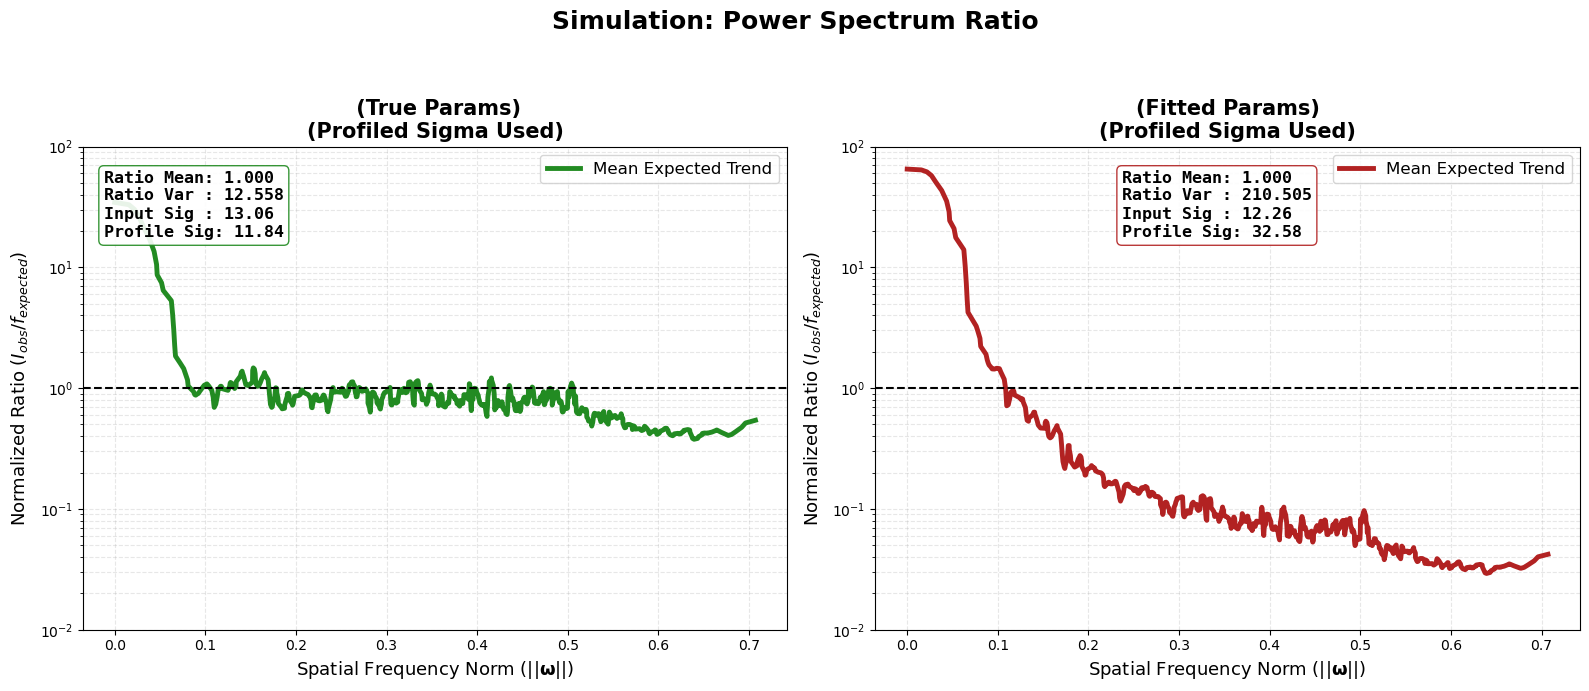

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftshift, fftfreq
from scipy.ndimage import gaussian_filter1d
import cmath
import sys
import pandas as pd

# =========================================================================
# 1. The Logic Class (Debiased Whittle Likelihood Core)
# =========================================================================
class debiased_whittle_likelihood:
    
    @staticmethod
    def cgn_hamming(u, n1, n2):
        u1, u2 = u
        device = u1.device if isinstance(u1, torch.Tensor) else (u2.device if isinstance(u2, torch.Tensor) else torch.device('cpu'))
        u1_tensor = u1.to(device) if isinstance(u1, torch.Tensor) else torch.tensor(u1, device=device, dtype=torch.float64)
        u2_tensor = u2.to(device) if isinstance(u2, torch.Tensor) else torch.tensor(u2, device=device, dtype=torch.float64)
        n1_eff = float(n1) if n1 > 0 else 1.0
        n2_eff = float(n2) if n2 > 0 else 1.0
        
        hamming1 = 0.54 - 0.46 * torch.cos(2.0 * torch.pi * u1_tensor / n1_eff)
        hamming2 = 0.54 - 0.46 * torch.cos(2.0 * torch.pi * u2_tensor / n2_eff)
        return hamming1 * hamming2

    @staticmethod
    def calculate_taper_autocorrelation_fft(taper_grid, n1, n2, device):
        taper_grid = taper_grid.to(device) 
        H = torch.sum(taper_grid**2)
        if H < 1e-12:
            return torch.zeros((2*n1-1, 2*n2-1), device=device, dtype=taper_grid.dtype)
        N1, N2 = 2 * n1 - 1, 2 * n2 - 1
        taper_fft = torch.fft.fft2(taper_grid, s=(N1, N2))
        power_spectrum = torch.abs(taper_fft)**2
        autocorr_unnormalized = torch.fft.ifft2(power_spectrum).real
        autocorr_shifted = torch.fft.fftshift(autocorr_unnormalized)
        return autocorr_shifted / (H + 1e-12)

    @staticmethod
    def expected_periodogram_fft_tapered(params, n1, n2, p_time, taper_autocorr_grid, delta1, delta2):
        device = params.device
        
        def cov_x_spatiotemporal_model_kernel(u1, u2, t, params):
            u1 = torch.as_tensor(u1, device=device, dtype=torch.float64)
            u2 = torch.as_tensor(u2, device=device, dtype=torch.float64)
            t  = torch.as_tensor(t, device=device, dtype=torch.float64)

            phi1, phi2, phi3, phi4 = torch.exp(params[0]), torch.exp(params[1]), torch.exp(params[2]), torch.exp(params[3])
            advec_lat, advec_lon = params[4], params[5]
            nugget = torch.exp(params[6])

            epsilon = 1e-12
            sigmasq = phi1 / (phi2 + epsilon)
            range_lon_inv = phi2
            range_lat_inv = torch.sqrt(phi3 + epsilon) * phi2
            beta_scaled_inv = torch.sqrt(phi4 + epsilon) * phi2 

            u1_adv = u1 - advec_lat * t
            u2_adv = u2 - advec_lon * t

            dist_sq = (u1_adv * range_lat_inv).pow(2) + (u2_adv * range_lon_inv).pow(2) + (t * beta_scaled_inv).pow(2)
            distance = torch.sqrt(dist_sq + epsilon)
            
            cov_smooth = sigmasq * torch.exp(-distance)
            is_zero_lag = (torch.abs(u1) < 1e-9) & (torch.abs(u2) < 1e-9) & (torch.abs(t) < 1e-9)
            return torch.where(is_zero_lag, cov_smooth + nugget, cov_smooth)

        def cov_spatial_difference(u1, u2, t, params, delta1, delta2):
            weights = {(0, 0): -2.0, (1, 0): 1.0, (0, 1): 1.0}
            cov = torch.zeros_like(u1, device=device, dtype=torch.float64)
            for (a, b), w_ab in weights.items():
                for (c, d), w_cd in weights.items():
                    lag_u1 = u1 + (a - c) * delta1
                    lag_u2 = u2 + (b - d) * delta2
                    cov += w_ab * w_cd * cov_x_spatiotemporal_model_kernel(lag_u1, lag_u2, t, params)
            return cov

        def cn_bar_tapered(u1, u2, t, params, n1, n2, taper_autocorr_grid, delta1, delta2):
            lag_u1 = u1 * delta1
            lag_u2 = u2 * delta2
            cov_val = cov_spatial_difference(lag_u1, lag_u2, t, params, delta1, delta2)
            idx1 = torch.clamp((n1 - 1 + u1).long(), 0, 2 * n1 - 2)
            idx2 = torch.clamp((n2 - 1 + u2).long(), 0, 2 * n2 - 2)
            taper_val = taper_autocorr_grid[idx1, idx2]
            return cov_val * taper_val

        u1_mesh, u2_mesh = torch.meshgrid(
            torch.arange(n1, dtype=torch.float64, device=device),
            torch.arange(n2, dtype=torch.float64, device=device),
            indexing='ij'
        )
        t_lags = torch.arange(p_time, dtype=torch.float64, device=device)
        tilde_cn_tensor = torch.zeros((n1, n2, p_time, p_time), dtype=torch.complex128, device=device)

        for q in range(p_time):
            for r in range(p_time):
                t_diff = t_lags[q] - t_lags[r]
                t1 = cn_bar_tapered(u1_mesh, u2_mesh, t_diff, params, n1, n2, taper_autocorr_grid, delta1, delta2)
                t2 = cn_bar_tapered(u1_mesh - n1, u2_mesh, t_diff, params, n1, n2, taper_autocorr_grid, delta1, delta2)
                t3 = cn_bar_tapered(u1_mesh, u2_mesh - n2, t_diff, params, n1, n2, taper_autocorr_grid, delta1, delta2)
                t4 = cn_bar_tapered(u1_mesh - n1, u2_mesh - n2, t_diff, params, n1, n2, taper_autocorr_grid, delta1, delta2)
                tilde_cn_tensor[:, :, q, r] = (t1 + t2 + t3 + t4).to(torch.complex128)

        fft_result = torch.fft.fft2(tilde_cn_tensor, dim=(0, 1)).real
        norm_factor = 1.0 / (4.0 * cmath.pi**2)
        return fft_result * norm_factor

# =========================================================================
# 2. Calculation Helper (MEAN CENTERING APPLIED)
# =========================================================================
def calculate_periodogram_ratio_sim(data_tensor, params_list_or_tensor, device):
    DELTA_LAT = 0.044 
    DELTA_LON = 0.063
    TAPERING_FUNC = debiased_whittle_likelihood.cgn_hamming 
    
    # 1. Parameter Extraction 
    if isinstance(params_list_or_tensor, list):
        params_tensor = torch.stack([p.view(-1) for p in params_list_or_tensor]).flatten().to(device, dtype=torch.float64)
    else:
        params_tensor = params_list_or_tensor.to(device, dtype=torch.float64)

    phi1_val = torch.exp(params_tensor[0]).item()
    phi2_val = torch.exp(params_tensor[1]).item()
    sigma_sq = phi1_val / phi2_val

    # 2. J Vector & Expected Periodogram
    cur_df = data_tensor
    unique_times = torch.unique(cur_df[:, 3])
    tensor_list = [cur_df[cur_df[:, 3] == t_val] for t_val in unique_times]
    p_time = len(tensor_list)

    # Grid size detection
    all_lats_cpu = torch.cat([t[:, 0] for t in tensor_list]).cpu()
    all_lons_cpu = torch.cat([t[:, 1] for t in tensor_list]).cpu()
    unique_lats_cpu, unique_lons_cpu = torch.unique(all_lats_cpu), torch.unique(all_lons_cpu)
    n1, n2 = len(unique_lats_cpu), len(unique_lons_cpu)

    lat_map = {lat.item(): i for i, lat in enumerate(unique_lats_cpu)}
    lon_map = {lon.item(): i for i, lon in enumerate(unique_lons_cpu)}

    u1_mesh_cpu, u2_mesh_cpu = torch.meshgrid(
        torch.arange(n1, dtype=torch.float64),
        torch.arange(n2, dtype=torch.float64),
        indexing='ij'
    )
    taper_grid = TAPERING_FUNC((u1_mesh_cpu, u2_mesh_cpu), n1, n2).to(device)

    fft_results = []
    for tensor in tensor_list:
        data_grid = torch.zeros((n1, n2), dtype=torch.float64, device=device)
        
        # [핵심 수정: Mean Centering]
        # 해당 시간대(Hour)의 유효한 데이터 평균을 구해서 뺍니다 (GLOBAL_MEAN 260 제거 효과)
        valid_vals = tensor[:, 2][~torch.isnan(tensor[:, 2])]
        spatial_mean = valid_vals.mean() if len(valid_vals) > 0 else 0.0

        for row in tensor:
            lat_val, lon_val, val = row[0].item(), row[1].item(), row[2].item()
            if not (np.isnan(lat_val) or np.isnan(lon_val) or np.isnan(val)):
                i = lat_map.get(lat_val)
                j = lon_map.get(lon_val)
                if i is not None and j is not None:
                    # 평균을 뺀 순수 변동성(Anomaly)만 그리드에 채워 넣습니다!
                    data_grid[i, j] = val - spatial_mean

        data_grid_tapered = data_grid * taper_grid 
        data_grid_tapered = torch.nan_to_num(data_grid_tapered, nan=0.0)
        fft_results.append(torch.fft.fft2(data_grid_tapered))

    J_vector_tensor = torch.stack(fft_results, dim=2)
    H = torch.sum(taper_grid**2)
    norm_factor = (torch.sqrt(1.0 / H) / (2.0 * cmath.pi)).to(device)
    J_vec = J_vector_tensor * norm_factor

    taper_autocorr_grid = debiased_whittle_likelihood.calculate_taper_autocorrelation_fft(
        taper_grid, n1, n2, device
    )

    with torch.no_grad():
        I_expected = debiased_whittle_likelihood.expected_periodogram_fft_tapered(
            params_tensor, n1, n2, p_time, taper_autocorr_grid, DELTA_LAT, DELTA_LON
        )

    # 3. Whitening Process
    eye = torch.eye(p_time, device=device, dtype=torch.complex128)
    try:
        L = torch.linalg.cholesky(I_expected + eye * 1e-9) 
    except RuntimeError:
        L = torch.linalg.cholesky(I_expected + eye * 1e-6)

    J_vec_expanded = J_vec.unsqueeze(-1) 
    Z_white = torch.linalg.solve_triangular(L, J_vec_expanded, upper=False)
    
    whitened_power = (Z_white.abs() ** 2).squeeze(-1) 
    
    # 공간축(0, 1) Shift 및 Flatten
    ratio_3d_shifted = np.fft.fftshift(whitened_power.cpu().numpy(), axes=(0, 1))
    ratio_raw = ratio_3d_shifted.flatten()
    
    # Profile Sigma 적용: 전체 평균을 구해서 1.0으로 스케일링
    scaling_factor = np.nanmean(ratio_raw)
    sigma_profile = sigma_sq * scaling_factor
    ratio_normalized = ratio_raw / scaling_factor
    
    # 주파수 배열 추출 (완벽한 ij 매핑)
    freq_lat = np.fft.fftshift(np.fft.fftfreq(n1))
    freq_lon = np.fft.fftshift(np.fft.fftfreq(n2))
    
    g_lat, g_lon = np.meshgrid(freq_lat, freq_lon, indexing='ij')
    freq_norm = np.sqrt(g_lat**2 + g_lon**2).flatten()
    freq_norm_expanded = np.repeat(freq_norm, p_time)
    
    # DC 성분(주파수 0)은 플롯 왜곡을 방지하기 위해 마스킹 처리(옵션, 여기서는 냅둡니다)
    
    return freq_norm_expanded, ratio_normalized, sigma_sq, sigma_profile

# =========================================================================
# 3. Simulation Plotting Function (Irregular vs Regular Vecchia)
# =========================================================================
def compare_periodogram_sim_1x2(grid_tensor, true_params, fitted_params, device):
    print("--- Generating Simulation Periodogram Comparison ---")
    
    print("Computing Irregular Vecchia (Expected via True Params)...")
    norm_irr, ratio_irr, sig_in_irr, sig_prof_irr = calculate_periodogram_ratio_sim(grid_tensor, true_params, device)
    
    print("Computing Regular Vecchia (Expected via Fitted Params)...")
    norm_reg, ratio_reg, sig_in_reg, sig_prof_reg = calculate_periodogram_ratio_sim(grid_tensor, fitted_params, device)

    fig, axs = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"Simulation: Power Spectrum Ratio", fontsize=18, fontweight='bold', y=0.98)
    
    ax_irr, ax_reg = axs[0], axs[1]
    
    def plot_column(ax, x, y, sig_input, sig_profile, title_prefix, color, is_right_plot=False):
        # 극단적인 아웃라이어(특히 주파수 0 부근)를 시각적으로 제한
        y_visual = np.clip(y, 1e-5, 100.0) 
            
        if len(x) > 0:
            df_trend = pd.DataFrame({'x': x, 'y': y_visual})
            mean_trend = df_trend.groupby('x').mean().sort_index()
            
            unique_x = mean_trend.index.values
            mean_y = mean_trend['y'].values
            
            trend_smooth = gaussian_filter1d(mean_y, sigma=2) 
            ax.plot(unique_x, trend_smooth, color=color, linewidth=3.5, label='Mean Expected Trend')

        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5)
        
        # Profile Out 했으므로 Mean은 1.0에 매우 가깝게 나옵니다.
        mean_val = np.nanmean(y) 
        var_val = np.nanvar(y)
        
        ax.set_yscale('log')
        ax.set_ylim(0.01, 100) 
        
        ax.set_title(f"{title_prefix}\n(Profiled Sigma Used)", fontsize=15, fontweight='bold')
        
        ax.set_xlabel(r'Spatial Frequency Norm ($||\mathbf{\omega}||$)', fontsize=13)
        ax.set_ylabel(r'Normalized Ratio ($I_{obs} / f_{expected}$)', fontsize=13)
        ax.grid(True, which="both", ls="--", alpha=0.3)
        
        stats_text = (f"Ratio Mean: {mean_val:.3f}\n"
                      f"Ratio Var : {var_val:.3f}\n"
                      f"Input Sig : {sig_input:.2f}\n"
                      f"Profile Sig: {sig_profile:.2f}")
        
        props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=color)
        
        x_pos = 0.35 if is_right_plot else 0.03
        ax.text(x_pos, 0.95, stats_text, transform=ax.transAxes, 
                fontsize=12, verticalalignment='top', bbox=props, fontweight='bold', fontfamily='monospace')
        
        ax.legend(loc='upper right', fontsize=12)

    plot_column(ax_irr, norm_irr, ratio_irr, sig_in_irr, sig_prof_irr, " (True Params)", "forestgreen", is_right_plot=False)
    plot_column(ax_reg, norm_reg, ratio_reg, sig_in_reg, sig_prof_reg, "(Fitted Params)", "firebrick", is_right_plot=True)
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# =========================================================================
# 4. 실행 부 (EXECUTION) - Direct Assignment
# =========================================================================
if __name__ == '__main__':
    try:
        DEVICE_SIM = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        print("✅ Loading DW Grid Data directly...")
        reg_data_tensor = daily_aggregated_dw_sim[0].to(DEVICE_SIM) 
        
        # -----------------------------------------------------------------
        # 2. 참값(True) 파라미터 
        # -----------------------------------------------------------------
        t_sigmasq   = 13.059
        t_range_lat = 0.154 
        t_range_lon = 0.195
        t_range_time= 1.0
        t_advec_lat = 0.0218
        t_advec_lon = -0.1689
        t_nugget    = 0.247

        t_phi2 = 1.0 / t_range_lon
        t_phi1 = t_sigmasq * t_phi2
        t_phi3 = (t_range_lon / t_range_lat)**2
        t_phi4 = (t_range_lon / t_range_time)**2

        true_params_list = [
            torch.tensor([np.log(t_phi1)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(t_phi2)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(t_phi3)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(t_phi4)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([t_advec_lat],    dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([t_advec_lon],    dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(t_nugget)],dtype=torch.float64, device=DEVICE_SIM)
        ]

        # -----------------------------------------------------------------
        # 3. 피팅된(Fitted) 파라미터 (Regular Vecchia)
        # -----------------------------------------------------------------
        f_sigmasq   = 12.813736802590302
        f_range_lon = 0.148432824307421
        f_range_lat = 0.15761657918676775
        f_range_time= 0.8822488694646387
        f_advec_lat = -0.10692136834042955
        f_advec_lon = -0.15471182109787696
        f_nugget    = 7.454706033774221e-07 # 붕괴된 Nugget


        f_sigmasq = 12.263766134415414
        f_range_lon = 0.03852656905329363
        f_range_lat = 0.02728920710861132
        f_range_time= 0.8688497612705166
        f_advec_lat = 0.006106149973616931
        f_advec_lon = 0.005110786159408905
        f_nugget    = 1.038744573665681

        f_phi2 = 1.0 / f_range_lon
        f_phi1 = f_sigmasq * f_phi2
        f_phi3 = (f_range_lon / f_range_lat)**2
        f_phi4 = (f_range_lon / f_range_time)**2

        fitted_params_list = [
            torch.tensor([np.log(f_phi1)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(f_phi2)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(f_phi3)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(f_phi4)], dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([f_advec_lat],    dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([f_advec_lon],    dtype=torch.float64, device=DEVICE_SIM),
            torch.tensor([np.log(f_nugget)],dtype=torch.float64, device=DEVICE_SIM)
        ]

        # 4. 비교 플롯 실행
        compare_periodogram_sim_1x2(
            grid_tensor=reg_data_tensor, 
            true_params=true_params_list, 
            fitted_params=fitted_params_list, 
            device=DEVICE_SIM
        )
        
    except Exception as e:
        print(f"Error가 발생했습니다: {e}")

# fit dw

difference data

In [31]:
subsetted_aggregated_day.shape

torch.Size([2728, 4])

In [41]:
daily_hourly_maps_reg_vecc_sim[day]['2024_07_y24m07day01_hm00:53'].shape

torch.Size([2835, 4])

In [6]:
a = [11.0474, 0.0623, 0.2445, 1.0972, 0.0101, -0.1671, 1.1825]
day = 0 # 0 index
lat_range= [-3, -1]
lon_range= [121, 125]
#lat_range= [1,3]
#lon_range= [125, 129.0]

daily_aggregated_tensors_dw = [daily_aggregated_dw_sim[day]]
daily_hourly_maps_dw = [daily_hourly_maps_dw_sim[day]]

db = debiased_whittle.debiased_whittle_preprocess(daily_aggregated_tensors_dw, daily_hourly_maps_dw, day_idx=day, params_list=a, lat_range=lat_range, lon_range=lon_range)


subsetted_aggregated_day = db.generate_spatially_filtered_days(-3,-1,121,125)
print(subsetted_aggregated_day.shape)
N2= subsetted_aggregated_day.shape[0]
print(N2)
subsetted_aggregated_day[:20]

torch.Size([22680, 4])
22680


tensor([[ -2.9800, 121.0000,  -4.3757,   0.0000],
        [ -2.9800, 121.0630,   5.8032,   0.0000],
        [ -2.9800, 121.1260,   1.1170,   0.0000],
        [ -2.9800, 121.1890,  -2.1063,   0.0000],
        [ -2.9800, 121.2520,   0.4625,   0.0000],
        [ -2.9800, 121.3150,   1.9560,   0.0000],
        [ -2.9800, 121.3780,   1.2727,   0.0000],
        [ -2.9800, 121.4410,  -2.4676,   0.0000],
        [ -2.9800, 121.5040,   0.2430,   0.0000],
        [ -2.9800, 121.5670,   4.0254,   0.0000],
        [ -2.9800, 121.6300,   5.2243,   0.0000],
        [ -2.9800, 121.6930,   8.9678,   0.0000],
        [ -2.9800, 121.7560, -10.6579,   0.0000],
        [ -2.9800, 121.8190,   2.2547,   0.0000],
        [ -2.9800, 121.8820,  -0.5641,   0.0000],
        [ -2.9800, 121.9450,   0.3427,   0.0000],
        [ -2.9800, 122.0080,  -6.9036,   0.0000],
        [ -2.9800, 122.0710,  11.7442,   0.0000],
        [ -2.9800, 122.1340,  -1.8260,   0.0000],
        [ -2.9800, 122.1970,   1.7467,   0.0000]],

In [7]:
from torch.nn import Parameter
dwl = debiased_whittle.debiased_whittle_likelihood()
if __name__ == '__main__':
    start_time = time.time()

    # --- Configuration ---
    DAY_TO_RUN = 3 # data is decided above
    TAPERING_FUNC = dwl.cgn_hamming # Use Hamming taper
    NUM_RUNS = 1
    MAX_STEPS = 20 # L-BFGS usually converges in far fewer steps
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {DEVICE}")

    DELTA_LAT, DELTA_LON = 0.044, 0.063 

    LAT_COL, LON_COL = 0, 1
    VAL_COL = 2 # Spatially differenced value
    TIME_COL = 3


    cur_df =subsetted_aggregated_day
    
    if cur_df.numel() == 0 or cur_df.shape[1] <= max(LAT_COL, LON_COL, VAL_COL, TIME_COL):
        print(f"Error: Data for Day {DAY_TO_RUN} is empty or invalid.")
        exit()

    unique_times = torch.unique(cur_df[:, TIME_COL])
    time_slices_list = [cur_df[cur_df[:, TIME_COL] == t_val] for t_val in unique_times]

    # --- 1. Pre-compute J-vector, Taper Grid, and Taper Autocorrelation ---
    print("Pre-computing J-vector (Hamming taper)...")
    
    # --- 💥 REVISED: Renamed 'p' to 'p_time' 💥 ---
    J_vec, n1, n2, p_time, taper_grid = dwl.generate_Jvector_tapered( 
        time_slices_list,
        tapering_func=TAPERING_FUNC, 
        lat_col=LAT_COL, lon_col=LON_COL, val_col=VAL_COL,
        device=DEVICE
    )

    if J_vec is None or J_vec.numel() == 0 or n1 == 0 or n2 == 0 or p_time == 0:
       print(f"Error: J-vector generation failed for Day {DAY_TO_RUN}.")
       exit()
       
    print("Pre-computing sample periodogram...")
    I_sample = dwl.calculate_sample_periodogram_vectorized(J_vec)

    print("Pre-computing Hamming taper autocorrelation...")
    taper_autocorr_grid = dwl.calculate_taper_autocorrelation_fft(taper_grid, n1, n2, DEVICE)

    if torch.isnan(I_sample).any() or torch.isinf(I_sample).any():
        print("Error: NaN/Inf in sample periodogram.")
        exit()
    if torch.isnan(taper_autocorr_grid).any() or torch.isinf(taper_autocorr_grid).any():
        print("Error: NaN/Inf in taper autocorrelation.")
        exit()

    print(f"Data grid: {n1}x{n2}, {p_time} time points. J-vector, Periodogram, Taper Autocorr on {DEVICE}.")
    # --- END REVISION ---

    # --- 2. Optimization Loop ---
    all_final_results = []
    all_final_losses = []

    for i in range(NUM_RUNS):
        print(f"\n{'='*30} Initialization Run {i+1}/{NUM_RUNS} {'='*30}")

        # --- 7-PARAMETER initialization ---
        ''' 
        init_sigmasq   = 15.0
        init_range_lat = 0.66 
        init_range_lon = 0.7 
        init_nugget    = 1.5
        init_beta      = 0.1  # Temporal range ratio
        init_advec_lat = 0.02
        init_advec_lon = -0.08
        '''
        init_sigmasq   = 13.059
        init_range_lat = 0.154 
        init_range_lon = 0.195
        init_advec_lat = 0.0218
        init_range_time = 0.7
        init_advec_lon = -0.1689
        init_nugget    = 0.247

        init_phi2 = 1.0 / init_range_lon
        init_phi1 = init_sigmasq * init_phi2
        init_phi3 = (init_range_lon / init_range_lat)**2
        # Change needed to match the spatial-temporal distance formula:
        init_phi4 = (init_range_lon / init_range_time)**2      # (range_lon / range_time)^2

        initial_params_values = [
            np.log(init_phi1),    # [0] log_phi1
            np.log(init_phi2),    # [1] log_phi2
            np.log(init_phi3),    # [2] log_phi3
            np.log(init_phi4),    # [3] log_phi4
            init_advec_lat,       # [4] advec_lat (NOT log)
            init_advec_lon,       # [5] advec_lon (NOT log)
            np.log(init_nugget)   # [6] log_nugget
        ]
        
        print(f"Starting with FIXED params (raw log-scale): {[round(p, 4) for p in initial_params_values]}")

        params_list = [
            Parameter(torch.tensor([val], dtype=torch.float64))
            for val in initial_params_values
        ]

        # Helper to define the boundary globally for clarity
        NUGGET_LOWER_BOUND = 0.05
        LOG_NUGGET_LOWER_BOUND = np.log(NUGGET_LOWER_BOUND) # Approx -2.9957

        # --- 💥 REVISED: Use L-BFGS Optimizer 💥 ---
        optimizer = torch.optim.LBFGS(
            params_list,
            lr=1.0,           # Initial step length for line search
            max_iter=20,      # Iterations per step
            history_size=100,
            line_search_fn="strong_wolfe", # Often more robust
            tolerance_grad=1e-5
        )
        # --- END REVISION ---

        print(f"Starting optimization run {i+1} on device {DEVICE} (Hamming, 7-param ST kernel, L-BFGS)...")
        
        # --- 💥 REVISED: Call L-BFGS trainer, pass p_time 💥 ---
        nat_params_str, phi_params_str, raw_params_str, loss, steps_run = dwl.run_lbfgs_tapered(
            params_list=params_list,
            optimizer=optimizer,
            I_sample=I_sample,
            n1=n1, n2=n2, p_time=p_time,
            taper_autocorr_grid=taper_autocorr_grid, 
            max_steps=MAX_STEPS,
            device=DEVICE
        )
        # --- END REVISION ---
        
        if loss is not None:
            all_final_results.append((nat_params_str, phi_params_str, raw_params_str))
            all_final_losses.append(loss)
        else:
            all_final_losses.append(float('inf'))

    print(f"\n\n{'='*25} Overall Result from Run {'='*25} {'='*25}")
    
    valid_losses = [l for l in all_final_losses if l is not None and l != float('inf')]

    if not valid_losses:
        print(f"The run failed or resulted in an invalid loss for Day {DAY_TO_RUN}.")
    else:
        best_loss = min(valid_losses)
        best_run_index = all_final_losses.index(best_loss)
        best_results = all_final_results[best_run_index]
        
        print(f"Best Run Loss: {best_loss} (after {steps_run} steps)")
        print(f"Final Parameters (Natural Scale): {best_results[0]}")
        print(f"Final Parameters (Phi Scale)    : {best_results[1]}")
        print(f"Final Parameters (Raw Log Scale): {best_results[2]}")

    end_time = time.time()
    print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Using device: cpu
Pre-computing J-vector (Hamming taper)...
Pre-computing sample periodogram...
Pre-computing Hamming taper autocorrelation...
Data grid: 45x63, 8 time points. J-vector, Periodogram, Taper Autocorr on cpu.

============================== Initialization Run 1/1 ==============================
Starting with FIXED params (raw log-scale): [4.2042, 1.6348, 0.4721, -2.5562, 0.0218, -0.1689, -1.3984]
Starting optimization run 1 on device cpu (Hamming, 7-param ST kernel, L-BFGS)...
--- Step 1/20 ---
 Loss: 1.829723 | Max Grad: 4.600702e-05
  Params (Raw Log): log_phi1: 4.1783, log_phi2: 1.5572, log_phi3: 0.3815, log_phi4: -3.4342, advec_lat: 0.0125, advec_lon: -0.1670, log_nugget: -0.7674
--- Step 2/20 ---
 Loss: 1.800890 | Max Grad: 4.600702e-05
  Params (Raw Log): log_phi1: 4.1783, log_phi2: 1.5572, log_phi3: 0.3815, log_phi4: -3.4342, advec_lat: 0.0125, advec_lon: -0.1670, log_nugget: -0.7674
--- Step 3/20 ---
 Loss: 1.800890 | Max Grad: 4.600702e-05
  Params (Raw Log): log_p